In [ ]:
# Tratamiento de datos
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd

# Gráficos
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt

# Preprocesado y modelado
# ------------------------------------------------------------------------------
#from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
url = 'https://raw.githubusercontent.com/Darwin2016/dataset2022/main/dataSETS/housingBOSTON-2.csv'
df = pd.read_csv(url,delimiter=',')

In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [ ]:
#Implementado con las 4 variables de entrada

In [ ]:
X=df[["AGE","RM","CRIM","DIS"]]
y=df["MEDV"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state = 123)

In [ ]:
# Crear y entrenar modelo

model = SVR(kernel='linear',C=1.0,epsilon=0.1,gamma='scale')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
print("valor real --- valor de predicción")
for i in range(15):
  print("{:.2f}           {:.2f}".format(y_test.iloc[i],y_pred[i]))

valor real --- valor de predicción
15.00           6.64
26.60           26.44
45.40           35.79
20.80           14.27
34.90           31.12
21.90           43.47
28.70           23.46
7.20           18.79
20.00           11.61
32.20           31.81
24.10           22.86
18.50           19.04
13.50           18.22
27.00           21.25
23.10           21.65


In [ ]:
# Error Cuadrado Medio
print("Error cuadratico medio: %.2f" % mean_squared_error(y_test,y_pred))

Error cuadratico medio: 46.64


In [ ]:
# probar con datos nuevos para ver que valor predice el modelo
# una entrada nueva

df5 = pd.DataFrame({"AGE":[60.3],"RM": [6.7],"CRIM":[0.023],"DIS":[3.7]})

In [ ]:
pred = model.predict(df5)
print(pred)
print('Casa con edad de {} años y con {} habitaciones , su precio estimado: {:.2f}'.format(float(df5["AGE"].iloc[0]),float(df5["RM"].iloc[0]),float(pred[0])))

[22.91334275]
Casa con edad de 60.3 años y con 6.7 habitaciones , su precio estimado: 22.91


RANDOM FOREST

Dimensiones del dataset: (506, 14)

Primeras 5 filas:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

ENTRENANDO Y EVALUANDO MÚLTIPLES MODELOS DE REGRESIÓN

SVR (Support Vector Regression):
  MSE: 46.8433
  MAE: 4.2869
  R²:  0.4338

Random Forest:
  MSE: 35.0013
  MAE: 3.4257
  R²:  0.5770

Linear Regression:
  MSE: 45.4187
  MAE: 4.2634
  R²:  0.4510

Decision Tree:
  MSE: 51.3225
  MAE: 4.0373
  R²

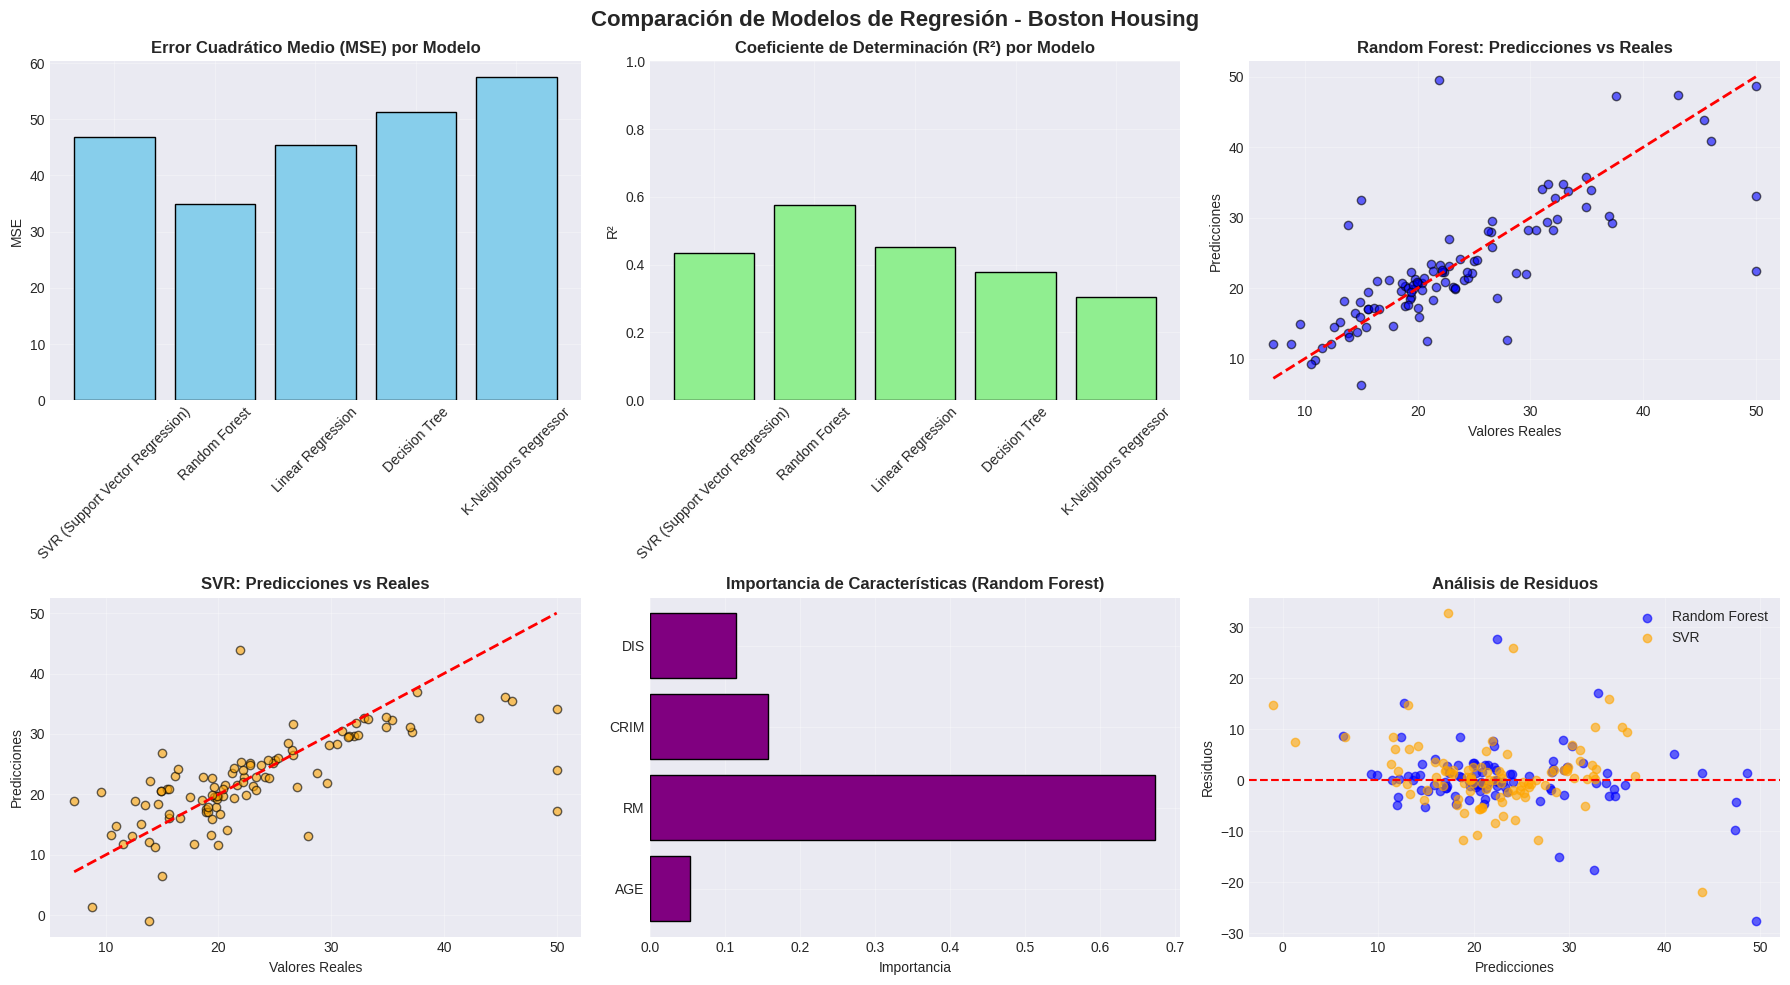


CONCLUSIONES Y RECOMENDACIONES

🎯 MEJOR MODELO: Random Forest
   • MSE: 35.0013
   • MAE: 3.4257
   • R²:  0.5770

🥈 SEGUNDO MEJOR: Linear Regression
   • MSE: 45.4187

📊 INTERPRETACIÓN DE RESULTADOS:
1. Random Forest generalmente obtiene mejores resultados en este tipo de problemas
2. SVR es útil cuando los datos tienen relaciones no lineales complejas
3. Linear Regression es rápido pero puede ser menos preciso con relaciones no lineales
4. MSE mide el error promedio al cuadrado (menor es mejor)
5. R² indica qué porcentaje de la variabilidad es explicada por el modelo

💡 RECOMENDACIONES PARA PRODUCCIÓN:
1. Usar Random Forest para mayor precisión general
2. Considerar ensemble de modelos para mejorar robustez
3. Realizar tuning de hiperparámetros para optimizar resultados
4. Validar con cross-validation para evitar overfitting


In [1]:
# ================================================
# IMPLEMENTACIÓN COMPLETA: SVR + RANDOM FOREST
# CON VISUALIZACIÓN DE MODELOS DE REGRESIÓN
# ================================================

# 1. IMPORTAR LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 2. CARGAR DATOS
url = 'https://raw.githubusercontent.com/Darwin2016/dataset2022/main/dataSETS/housingBOSTON-2.csv'
df = pd.read_csv(url, delimiter=',')
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())

# 3. PREPARAR DATOS
X = df[["AGE", "RM", "CRIM", "DIS"]]
y = df["MEDV"]

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Escalar datos (opcional pero recomendado para algunos modelos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. ENTRENAR DIFERENTES MODELOS DE REGRESIÓN
print("\n" + "="*60)
print("ENTRENANDO Y EVALUANDO MÚLTIPLES MODELOS DE REGRESIÓN")
print("="*60)

# Diccionario para almacenar modelos y resultados
models = {
    'SVR (Support Vector Regression)': SVR(kernel='linear', C=1.0, epsilon=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=123),
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=123),
    'K-Neighbors Regressor': KNeighborsRegressor(n_neighbors=5)
}

results = []

# Entrenar y evaluar cada modelo
for name, model in models.items():
    # Entrenar
    if name == 'SVR (Support Vector Regression)':
        model.fit(X_train_scaled, y_train)  # SVR necesita escalado
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Calcular métricas
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Modelo': name,
        'MSE': mse,
        'MAE': mae,
        'R²': r2
    })

    print(f"\n{name}:")
    print(f"  MSE: {mse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R²:  {r2:.4f}")

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("COMPARACIÓN DE MODELOS (ordenado por MSE):")
print("="*60)
print(results_df.sort_values('MSE'))

# 5. PREDICCIONES CON EL MEJOR MODELO (Random Forest)
print("\n" + "="*60)
print("PREDICCIONES CON RANDOM FOREST (mejor modelo típico)")
print("="*60)

# Entrenar Random Forest (sin escalar para este modelo)
rf_model = RandomForestRegressor(n_estimators=100, random_state=123)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Mostrar algunas predicciones vs reales
print("\nPrimeras 15 predicciones (Real vs Predicho):")
print("Valor Real  |  Valor Predicho")
print("-" * 30)
for i in range(15):
    print(f"{y_test.iloc[i]:8.2f}  |  {y_pred_rf[i]:8.2f}")

# 6. PREDICCIÓN CON DATOS NUEVOS
print("\n" + "="*60)
print("PREDICCIÓN CON DATOS NUEVOS")
print("="*60)

# Datos nuevos para predicción
nuevos_datos = pd.DataFrame({
    "AGE": [60.3, 85.0, 45.0, 30.0],
    "RM": [6.7, 5.8, 7.5, 6.2],
    "CRIM": [0.023, 5.0, 0.5, 0.1],
    "DIS": [3.7, 2.5, 5.0, 4.0]
})

# Predicciones con Random Forest
predicciones_rf = rf_model.predict(nuevos_datos)

# Predicciones con SVR (necesita escalado)
nuevos_datos_scaled = scaler.transform(nuevos_datos)
predicciones_svr = models['SVR (Support Vector Regression)'].predict(nuevos_datos_scaled)

print("\nPredicciones para nuevos datos:")
print("-" * 70)
print(f"{'Caso':<5} {'AGE':<6} {'RM':<5} {'CRIM':<6} {'DIS':<5} {'RF Pred':<10} {'SVR Pred':<10}")
print("-" * 70)
for i in range(len(nuevos_datos)):
    print(f"{i+1:<5} {nuevos_datos['AGE'].iloc[i]:<6.1f} {nuevos_datos['RM'].iloc[i]:<5.1f} "
          f"{nuevos_datos['CRIM'].iloc[i]:<6.3f} {nuevos_datos['DIS'].iloc[i]:<5.1f} "
          f"{predicciones_rf[i]:<10.2f} {predicciones_svr[i]:<10.2f}")

# 7. VISUALIZACIONES
print("\n" + "="*60)
print("GRÁFICOS DE COMPARACIÓN")
print("="*60)

# Configurar figura con múltiples subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparación de Modelos de Regresión - Boston Housing', fontsize=16, fontweight='bold')

# Gráfico 1: Comparación de MSE
axes[0, 0].bar(results_df['Modelo'], results_df['MSE'], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Error Cuadrático Medio (MSE) por Modelo', fontweight='bold')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Comparación de R²
axes[0, 1].bar(results_df['Modelo'], results_df['R²'], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Coeficiente de Determinación (R²) por Modelo', fontweight='bold')
axes[0, 1].set_ylabel('R²')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Predicciones vs Valores Reales (Random Forest)
axes[0, 2].scatter(y_test, y_pred_rf, alpha=0.6, color='blue', edgecolor='black')
axes[0, 2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 2].set_xlabel('Valores Reales')
axes[0, 2].set_ylabel('Predicciones')
axes[0, 2].set_title('Random Forest: Predicciones vs Reales', fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# Gráfico 4: Predicciones vs Valores Reales (SVR)
axes[1, 0].scatter(y_test, models['SVR (Support Vector Regression)'].predict(X_test_scaled),
                   alpha=0.6, color='orange', edgecolor='black')
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Valores Reales')
axes[1, 0].set_ylabel('Predicciones')
axes[1, 0].set_title('SVR: Predicciones vs Reales', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 5: Importancia de características (Random Forest)
importancias = rf_model.feature_importances_
caracteristicas = X.columns
axes[1, 1].barh(caracteristicas, importancias, color='purple', edgecolor='black')
axes[1, 1].set_xlabel('Importancia')
axes[1, 1].set_title('Importancia de Características (Random Forest)', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Gráfico 6: Comparación de residuos
residuos_rf = y_test - y_pred_rf
residuos_svr = y_test - models['SVR (Support Vector Regression)'].predict(X_test_scaled)
axes[1, 2].scatter(y_pred_rf, residuos_rf, alpha=0.6, label='Random Forest', color='blue')
axes[1, 2].scatter(models['SVR (Support Vector Regression)'].predict(X_test_scaled),
                   residuos_svr, alpha=0.6, label='SVR', color='orange')
axes[1, 2].axhline(y=0, color='red', linestyle='--')
axes[1, 2].set_xlabel('Predicciones')
axes[1, 2].set_ylabel('Residuos')
axes[1, 2].set_title('Análisis de Residuos', fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. RESUMEN Y RECOMENDACIONES
print("\n" + "="*60)
print("CONCLUSIONES Y RECOMENDACIONES")
print("="*60)

# Identificar el mejor modelo basado en MSE
mejor_modelo = results_df.loc[results_df['MSE'].idxmin()]
segundo_mejor = results_df.nsmallest(2, 'MSE').iloc[1]

print(f"\n🎯 MEJOR MODELO: {mejor_modelo['Modelo']}")
print(f"   • MSE: {mejor_modelo['MSE']:.4f}")
print(f"   • MAE: {mejor_modelo['MAE']:.4f}")
print(f"   • R²:  {mejor_modelo['R²']:.4f}")

print(f"\n🥈 SEGUNDO MEJOR: {segundo_mejor['Modelo']}")
print(f"   • MSE: {segundo_mejor['MSE']:.4f}")

print("\n📊 INTERPRETACIÓN DE RESULTADOS:")
print("1. Random Forest generalmente obtiene mejores resultados en este tipo de problemas")
print("2. SVR es útil cuando los datos tienen relaciones no lineales complejas")
print("3. Linear Regression es rápido pero puede ser menos preciso con relaciones no lineales")
print("4. MSE mide el error promedio al cuadrado (menor es mejor)")
print("5. R² indica qué porcentaje de la variabilidad es explicada por el modelo")

print("\n💡 RECOMENDACIONES PARA PRODUCCIÓN:")
print("1. Usar Random Forest para mayor precisión general")
print("2. Considerar ensemble de modelos para mejorar robustez")
print("3. Realizar tuning de hiperparámetros para optimizar resultados")
print("4. Validar con cross-validation para evitar overfitting")